In [5]:
import sys
sys.path.insert(1, "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod")

import tod.corpus
import tod.outliers
import tod.clustering
import tod.plotting

corpus = tod.corpus.Corpus(
    treebank_path="/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master",
    grew_pattern="pattern {X[upos=ADV]} without {X[InIdiom=Yes];X[Idiom=Yes]}",
    patterns_text_file="../3. probability_matrix/patterns_adv.txt",
    matrix_type="coverage"
)

connected to port: 61977


Number of matches after filtering: 11701


In [2]:
import numpy as np
with open('x_65dims.npy', 'rb') as f:
    X = np.load(f)

In [ ]:
from minisom import MiniSom
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# # Normalize the data
# scaler = MinMaxScaler()
# X_normalized = scaler.fit_transform(X)

X_normalized = X
# Initialize the SOM
som = MiniSom(x=20, y=20, input_len=X.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_normalized)

# Train the SOM
som.train_random(X_normalized, num_iteration=10000)

# Map each data point to its winning neuron
winning_neurons = np.array([som.winner(x) for x in X_normalized])

# Group data points by their winning neurons
clusters = {}
for i, neuron in enumerate(winning_neurons):
    neuron = tuple(neuron)  # Convert numpy array to tuple
    if neuron not in clusters:
        clusters[neuron] = []
    clusters[neuron].append(i)

# # Map cluster indices back to original data (adv keys)
clustered_data = {}
for neuron, indices in clusters.items():

    clustered_data[neuron] = [corpus.idx2lexunit(i) for i in indices]

# Print the clusters with original data keys
# for neuron, adv_keys in clustered_data.items():
#     print(f"Neuron {neuron}: {adv_keys}")


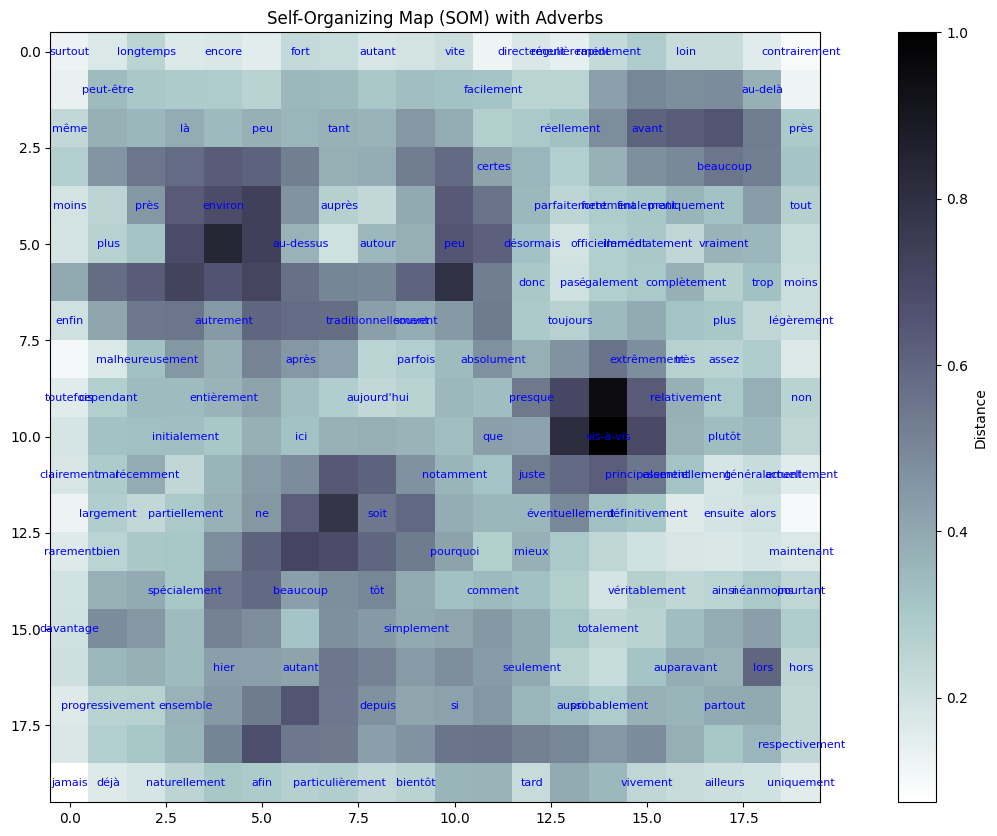

In [4]:
# Visualize the SOM with adverbs in each square
plt.figure(figsize=(20, 10))

# Iterate over the clusters and plot the adverbs in each neuron
for neuron, indices in clusters.items():
    # Extract the adverbs corresponding to the indices
    adverbs = [corpus.idx2lexunit(i)[0] for i in indices]  # Extract the adverb part from the tuple
    adverbs_text = "\n".join(adverbs)  # Join adverbs with line breaks for better readability
    
    # Plot the adverbs in the corresponding neuron square
    plt.text(neuron[0], neuron[1], adverbs_text, 
             color='blue', fontsize=8, ha='center', va='center', wrap=True)

# Add the distance map as the background
plt.title("Self-Organizing Map (SOM) with Adverbs")
plt.imshow(som.distance_map().T, cmap='bone_r')  # Distance map as background
plt.colorbar(label='Distance')
plt.show()

In [71]:
# get quantization error
som.quantization_error(X_normalized)

0.00024232603974919098

In [72]:
# get topographic error
som.topographic_error(X_normalized)

0.015503875968992248

In [76]:
som.distance_map()

array([[0.35483897, 0.35831778, 0.40054947, 0.34441548, 0.292957  ,
        0.37938395, 0.34288698, 0.39443001, 0.33226283, 0.36551426,
        0.29433372, 0.49602072, 0.44713972, 0.60094816, 0.32891688,
        0.32045156, 0.31349847, 0.46733389, 0.59336927, 0.2530413 ],
       [0.3274271 , 0.61304806, 0.68629489, 0.64346396, 0.58602363,
        0.508573  , 0.53819705, 0.5228764 , 0.57140129, 0.58113209,
        0.4948716 , 0.68648447, 1.        , 0.72138856, 0.43130997,
        0.47205634, 0.66180446, 0.856066  , 0.74379135, 0.46977586],
       [0.33530946, 0.37467245, 0.51050075, 0.70160415, 0.57935552,
        0.48761519, 0.39475867, 0.43914684, 0.67857068, 0.61353393,
        0.50960062, 0.58916179, 0.51263913, 0.41272844, 0.19618391,
        0.53851629, 0.75298464, 0.60525083, 0.48216101, 0.35906042],
       [0.48411389, 0.62653128, 0.63254434, 0.74655815, 0.50897307,
        0.43508521, 0.34400849, 0.41186023, 0.48227462, 0.6581876 ,
        0.51465989, 0.50216441, 0.35772254, 0

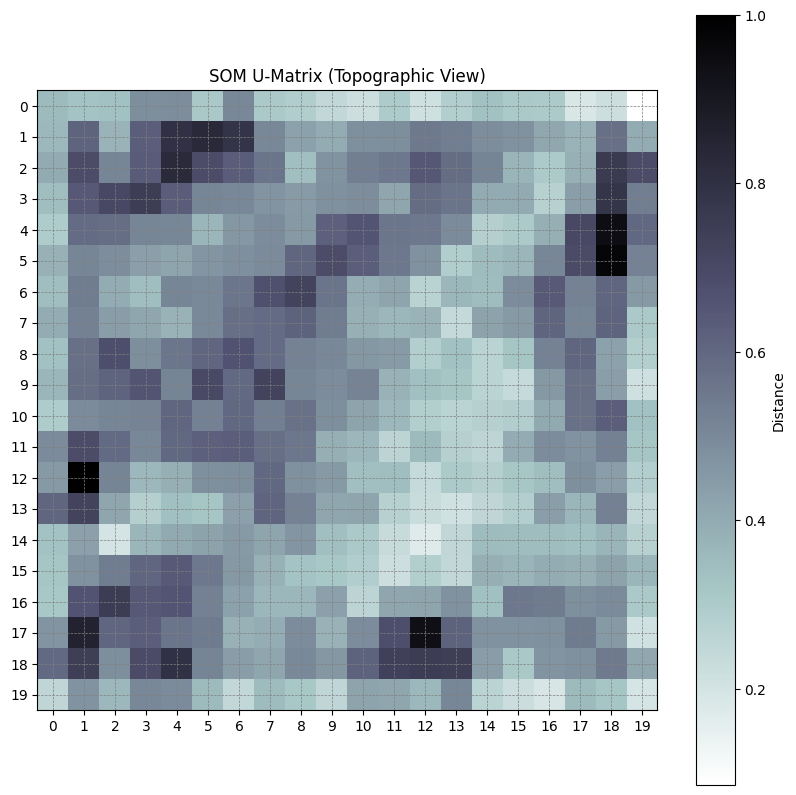

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming `distance_map` is your SOM distance map
distance_map = som.distance_map()

# Plot the U-matrix as a heatmap
plt.figure(figsize=(10, 10))
plt.title("SOM U-Matrix (Topographic View)")
plt.imshow(distance_map.T, cmap='bone_r', interpolation='nearest')  # Transpose for correct orientation
plt.colorbar(label='Distance')  # Add a color bar to indicate distance values
plt.xticks(np.arange(distance_map.shape[0]))
plt.yticks(np.arange(distance_map.shape[1]))
plt.grid(which='both', color='gray', linestyle='--', linewidth=0.5)
plt.show()

In [96]:
import plotly.graph_objects as go
import numpy as np

# Assuming `distance_map` is your SOM distance map
distance_map = som.distance_map()

# Create a 3D surface plot for the U-Matrix
fig = go.Figure()

# Add the U-Matrix as a surface
fig.add_trace(go.Surface(
    z=distance_map.T,  # Transpose to align axes correctly
    colorscale='Viridis',  # Choose a color scale
    colorbar=dict(title="Distance"),  # Add a color bar
    showscale=True,
    hoverinfo='none',  # Disable hover info for the surface
))

# Overlay words from clustered_data as hover text
for neuron, words in clustered_data.items():
    # Combine the words into a single string (e.g., separated by commas or line breaks)
    words_text = ", ".join([str(word) for word in words])  # Assuming `word[0]` contains the actual word
    
    # Format hover text to include x, y, z, and the words
    hover_text = f"Lexical unit: {words_text}<br>X: {neuron[0]}<br>Y: {neuron[1]}<br>Z: {distance_map[neuron[0], neuron[1]]:.3f}"
    
    fig.add_trace(go.Scatter3d(
        x=[neuron[0] + 0.5],  # Offset to center the text in the grid cell
        y=[neuron[1] + 0.5],
        z=[distance_map[neuron[0], neuron[1]] + 0.1],  # Slightly above the surface for visibility
        mode='markers',  # Use markers to indicate neuron positions
        marker=dict(size=5, color='red', opacity=0.8),  # Customize marker appearance
        hovertext=hover_text,  # Add combined hover text
        hoverinfo="text",  # Display only the hover text
        name=f"Neuron {neuron}"
    ))

# Customize layout
fig.update_layout(
    title="Interactive 3D Visualization of SOM with Combined Hover Text",
    scene=dict(
        xaxis_title="SOM X",
        yaxis_title="SOM Y",
        zaxis_title="Distance",
        xaxis=dict(nticks=distance_map.shape[0]),
        yaxis=dict(nticks=distance_map.shape[1])
    ),
    margin=dict(l=0, r=0, t=50, b=0)
)

# Show the interactive plot
fig.show()

In [18]:
# Create a scatter plot
import plotly.graph_objects as go
fig = go.Figure()

# Add a scatter trace for each neuron
for neuron, words in clustered_data.items():
    fig.add_trace(go.Scatter(
        x=[neuron[0]],
        y=[neuron[1]],
        text=[words],  # Join words with line breaks for hover text
        mode='markers+text',
        marker=dict(size=10),
        textfont=dict(size=10),
        hoverinfo='text'
    ))

# Update layout
fig.update_layout(
    title="Self-Organizing Map (SOM) with Clusters",
    xaxis=dict(title='X Coordinate', tickvals=list(range(65))),
    yaxis=dict(title='Y Coordinate', tickvals=list(range(65)), scaleanchor="x"),
    width=1000,
    height=1000
)

# Show the figure
fig.show()

/opt/homebrew/lib/python3.11/site-packages/minisom.py:631: RuntimeWarning:

invalid value encountered in sqrt



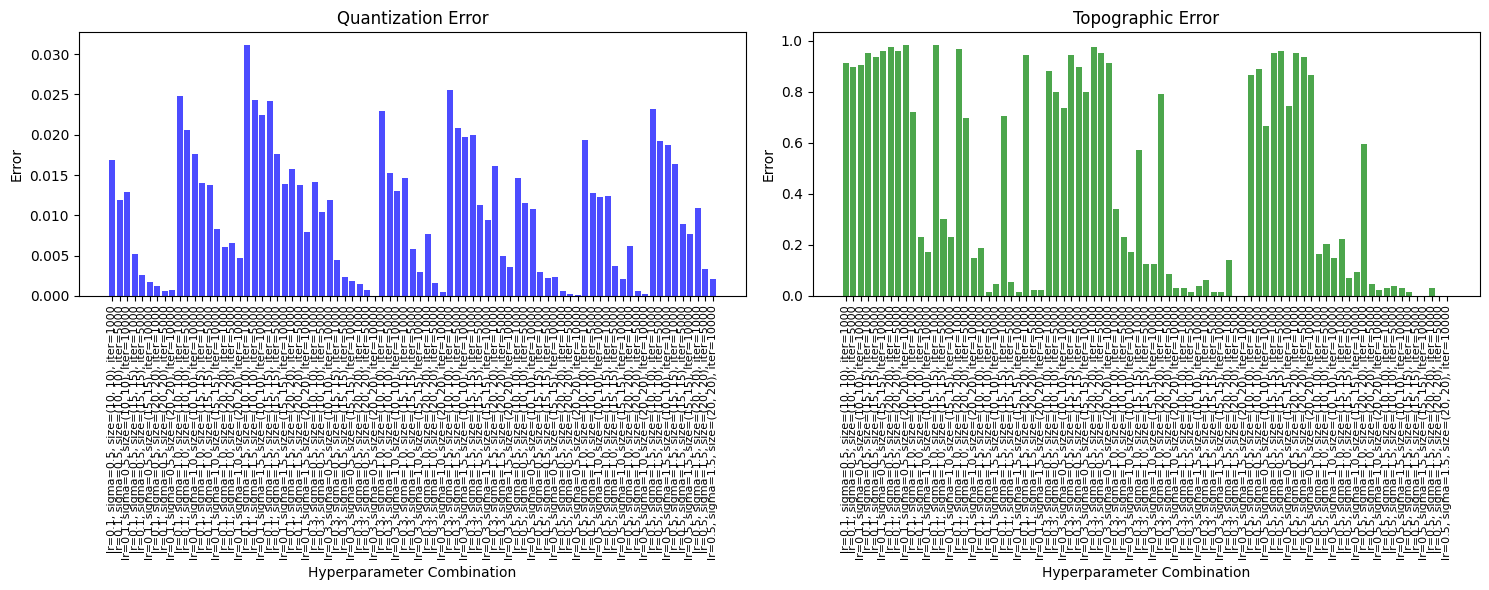

In [ ]:
from minisom import MiniSom
import numpy as np
import matplotlib.pyplot as plt

# Define ranges for hyperparameters
learning_rates = [0.1, 0.3, 0.5]
sigmas = [0.5, 1.0, 1.5]
lattice_sizes = [(10, 10), (15, 15), (20, 20)]
num_iterations = [1000, 5000, 10000]

# Store results
results = []

# Iterate over all combinations of hyperparameters
for lr in learning_rates:
    for sigma in sigmas:
        for size in lattice_sizes:
            for iterations in num_iterations:
                # Initialize the SOM
                som = MiniSom(x=size[0], y=size[1], input_len=X_normalized.shape[1], sigma=sigma, learning_rate=lr)
                som.random_weights_init(X_normalized)
                
                # Train the SOM
                som.train_random(X_normalized, num_iteration=iterations)
                
                # Compute errors
                quantization_error = som.quantization_error(X_normalized)
                topographic_error = som.topographic_error(X_normalized)
                
                # Store the results
                results.append({
                    'learning_rate': lr,
                    'sigma': sigma,
                    'lattice_size': size,
                    'num_iterations': iterations,
                    'quantization_error': quantization_error,
                    'topographic_error': topographic_error
                })

# Convert results to a structured format for plotting
quantization_errors = [r['quantization_error'] for r in results]
topographic_errors = [r['topographic_error'] for r in results]
labels = [f"lr={r['learning_rate']}, sigma={r['sigma']}, size={r['lattice_size']}, iter={r['num_iterations']}" for r in results]

# Plot the errors
plt.figure(figsize=(15, 6))

# Plot quantization error
plt.subplot(2, 1)
plt.bar(range(len(quantization_errors)), quantization_errors, color='blue', alpha=0.7)
plt.xticks(range(len(labels)), labels, rotation=90, fontsize=8)
plt.title("Quantization Error")
plt.ylabel("Error")
plt.xlabel("Hyperparameter Combination")

# Plot topographic error
plt.subplot(1, 2, 2)
plt.bar(range(len(topographic_errors)), topographic_errors, color='green', alpha=0.7)
plt.xticks(range(len(labels)), labels, rotation=90, fontsize=8)
plt.title("Topographic Error")
plt.ylabel("Error")
plt.xlabel("Hyperparameter Combination")

plt.tight_layout()
plt.show()

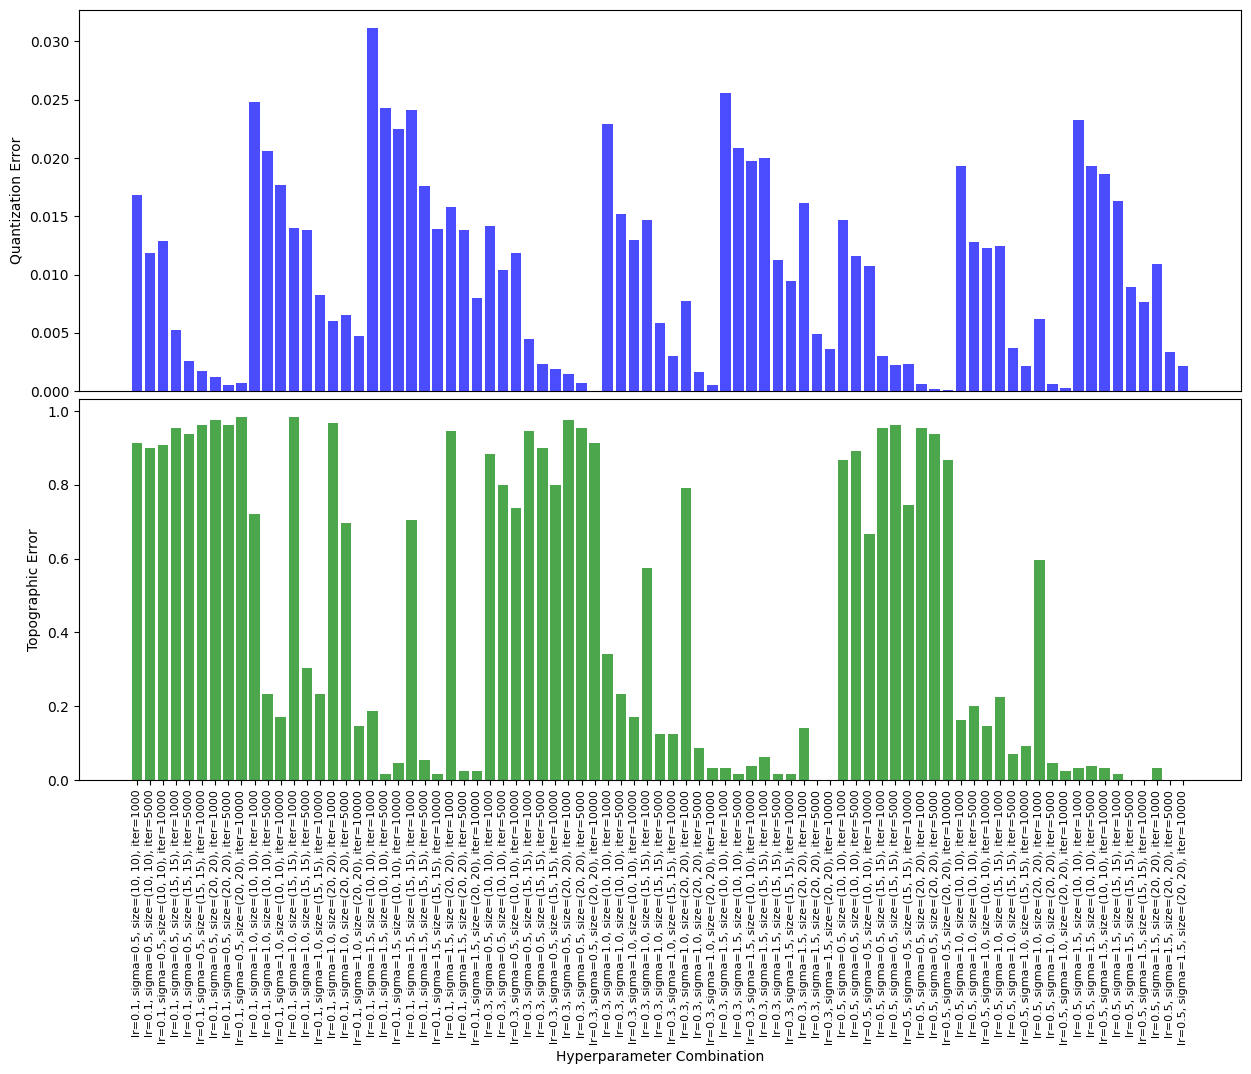

In [68]:
# Plot the errors
# Plot the errors
plt.figure(figsize=(15, 10))  # Increase figure height for better spacing

# Plot quantization error
plt.subplot(2, 1, 1)  # First subplot (2 rows, 1 column, position 1)
plt.bar(range(len(quantization_errors)), quantization_errors, color='blue', alpha=0.7)
plt.xticks([])  # Remove x-axis labels for the first plot
# plt.title("Quantization Error")
plt.ylabel("Quantization Error")

# Plot topographic error
plt.subplot(2, 1, 2)  # Second subplot (2 rows, 1 column, position 2)
plt.bar(range(len(topographic_errors)), topographic_errors, color='green', alpha=0.7)
plt.xticks(range(len(labels)), labels, rotation=90, fontsize=8)  # Add x-axis labels only here
# plt.title("Topographic Error")
plt.ylabel("Topographic Error")
plt.xlabel("Hyperparameter Combination")

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.02)

plt.show()

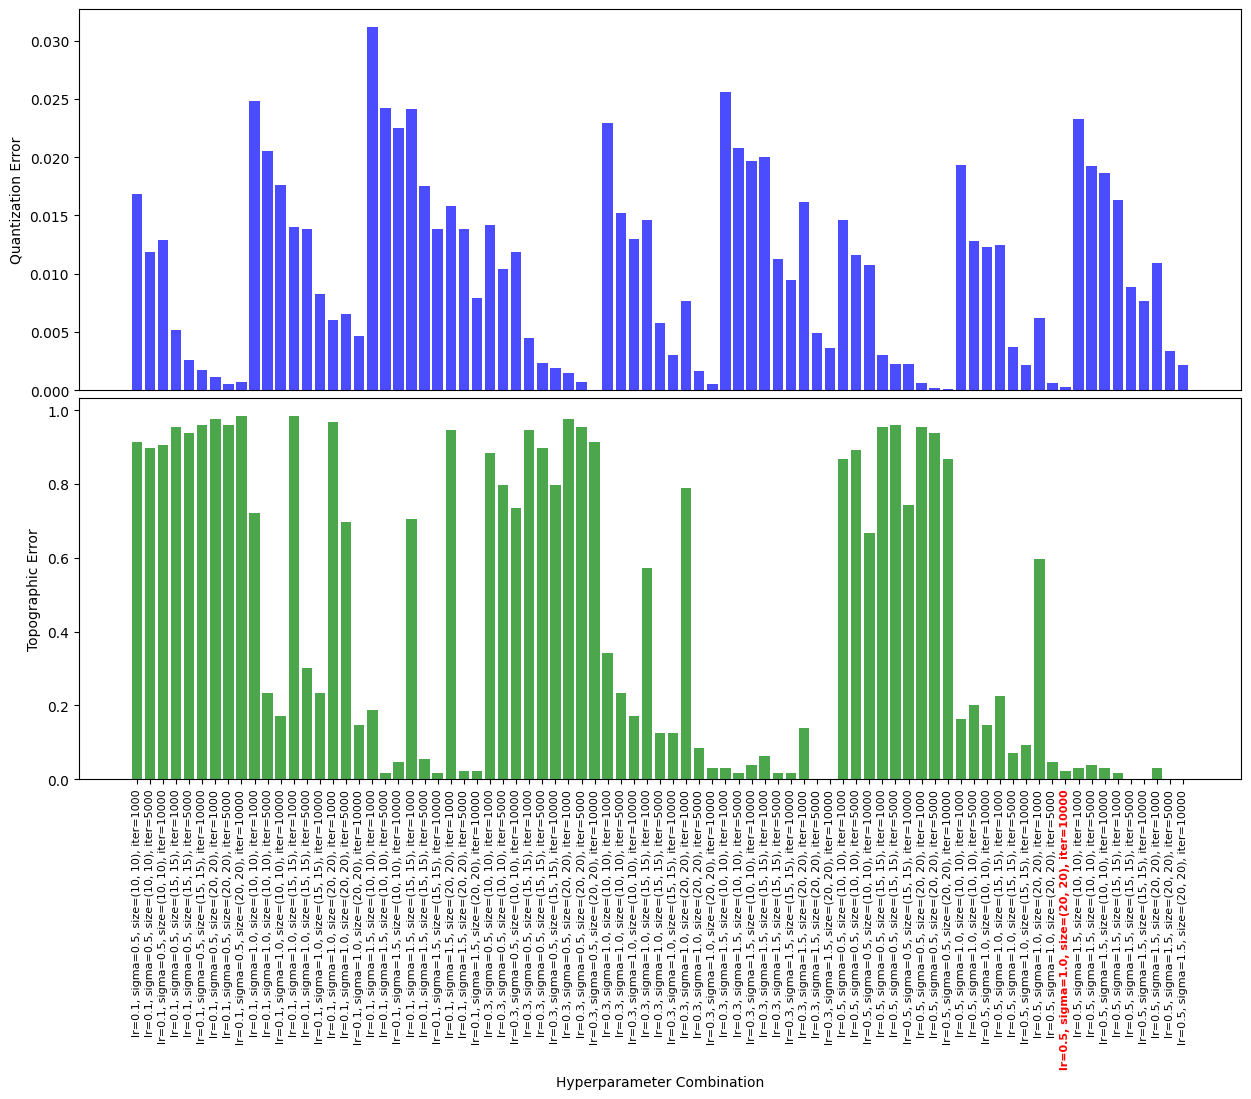

Best compromise hyperparameter combination: lr=0.5, sigma=1.0, size=(20, 20), iter=10000


In [86]:
# Normalize the errors to bring them to the same scale
quantization_errors_norm = (quantization_errors - np.min(quantization_errors)) / (np.max(quantization_errors) - np.min(quantization_errors))
topographic_errors_norm = (topographic_errors - np.min(topographic_errors)) / (np.max(topographic_errors) - np.min(topographic_errors))

# Compute the combined score (sum of normalized errors)
combined_scores = quantization_errors_norm + topographic_errors_norm

# Find the index of the best compromise (minimum combined score)
best_compromise_idx = np.argmin(combined_scores)

# Highlight the x-axis label for the best compromise
plt.figure(figsize=(15, 10))  # Increase figure height for better spacing

# Plot quantization error
plt.subplot(2, 1, 1)  # First subplot (2 rows, 1 column, position 1)
plt.bar(range(len(quantization_errors)), quantization_errors, color='blue', alpha=0.7)
plt.xticks([])  # Remove x-axis labels for the first plot
plt.ylabel("Quantization Error")

# Plot topographic error
plt.subplot(2, 1, 2)  # Second subplot (2 rows, 1 column, position 2)
plt.bar(range(len(topographic_errors)), topographic_errors, color='green', alpha=0.7)

# Highlight the x-axis label for the best compromise
x_labels = labels.copy()
xticks = plt.xticks(range(len(labels)), x_labels, rotation=90, fontsize=8)
for i, label in enumerate(xticks[1]):  # xticks[1] contains the Text objects for the labels
    if i == best_compromise_idx:
        label.set_color('red')  # Highlight the label in red
        label.set_fontweight('bold')  # Optionally make it bold

plt.ylabel("Topographic Error")
plt.xlabel("Hyperparameter Combination")

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.02)

plt.show()

# Print the best compromise hyperparameter combination
print(f"Best compromise hyperparameter combination: {labels[best_compromise_idx]}")

In [8]:
import numpy as np
from minisom import MiniSom
types_of_matrix = ["precision", "coverage", "PMI", "tf-idf", "geometric_mean"]
orig_dims = {}
for type_of_matrix in types_of_matrix:
    orig_dims[type_of_matrix] = {}
    with open(f"{type_of_matrix}_orig_dims.npy", 'rb') as f:
        X = np.load(f)
    X_normalized = X
    # Initialize the SOM
    som = MiniSom(x=20, y=20, input_len=X.shape[1], sigma=1.0, learning_rate=0.5)
    som.random_weights_init(X_normalized)

    # Train the SOM
    som.train_random(X_normalized, num_iteration=10000)

    # Map each data point to its winning neuron
    winning_neurons = np.array([som.winner(x) for x in X_normalized])

    orig_dims[type_of_matrix]["quantization_error"] = som.quantization_error(X_normalized)
    orig_dims[type_of_matrix]["topographic_error"] = som.topographic_error(X_normalized)
    # Group data points by their winning neurons
    clusters = {}
    for i, neuron in enumerate(winning_neurons):
        neuron = tuple(neuron)  # Convert numpy array to tuple
        if neuron not in orig_dims[type_of_matrix]:
            orig_dims[type_of_matrix][neuron] = []
        orig_dims[type_of_matrix][neuron].append(i)


/opt/homebrew/lib/python3.11/site-packages/minisom.py:631: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(-2 * cross_term + input_data_sq + weights_flat_sq.T)


In [9]:
import numpy as np
from minisom import MiniSom
types_of_matrix = ["precision", "coverage", "PMI", "tf-idf", "geometric_mean"]
red_dims = {}
for type_of_matrix in types_of_matrix:
    red_dims[type_of_matrix] = {}
    with open(f"{type_of_matrix}_reduced_dims.npy", 'rb') as f:
        X = np.load(f)
    X_normalized = X
    # Initialize the SOM
    som = MiniSom(x=20, y=20, input_len=X.shape[1], sigma=1.0, learning_rate=0.5)
    som.random_weights_init(X_normalized)

    # Train the SOM
    som.train_random(X_normalized, num_iteration=10000)

    # Map each data point to its winning neuron
    winning_neurons = np.array([som.winner(x) for x in X_normalized])

    red_dims[type_of_matrix]["quantization_error"] = som.quantization_error(X_normalized)
    red_dims[type_of_matrix]["topographic_error"] = som.topographic_error(X_normalized)
    # Group data points by their winning neurons
    clusters = {}
    for i, neuron in enumerate(winning_neurons):
        neuron = tuple(neuron)  # Convert numpy array to tuple
        if neuron not in red_dims[type_of_matrix]:
            red_dims[type_of_matrix][neuron] = []
        red_dims[type_of_matrix][neuron].append(i)

In [10]:
for type_of_matrix in types_of_matrix:
    print(f"{type_of_matrix} - {orig_dims[type_of_matrix]['quantization_error']}, {orig_dims[type_of_matrix]['topographic_error']}")

precision - 0.006224148852165654, 0.07751937984496124
coverage - 0.0005138075226206826, 0.031007751937984496
PMI - 0.059843081411771616, 0.015503875968992248
tf-idf - 0.0011120554344612949, 0.007751937984496124
geometric_mean - 0.001017641648093356, 0.05426356589147287


In [11]:
for type_of_matrix in types_of_matrix:
    print(f"{type_of_matrix} - {red_dims[type_of_matrix]['quantization_error']}, {red_dims[type_of_matrix]['topographic_error']}")

precision - 0.0001825637537506512, 0.03875968992248062
coverage - 0.0005827575375584476, 0.007751937984496124
PMI - 0.05478854856179996, 0.007751937984496124
tf-idf - 0.0006270913117202497, 0.015503875968992248
geometric_mean - 0.0003400149139950058, 0.015503875968992248


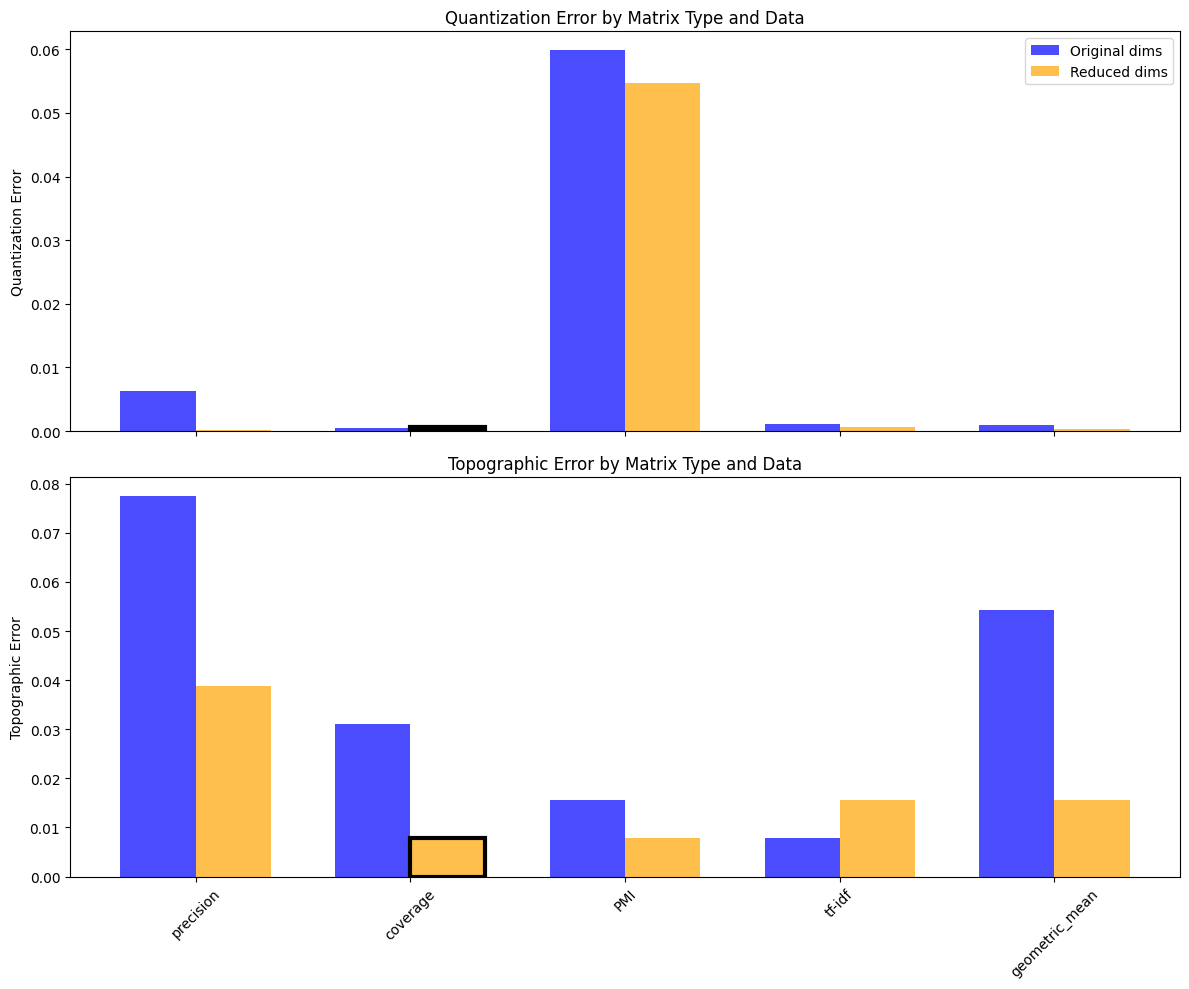

Best compromise: coverage (Reduced dims)


In [16]:
quantization_errors_orig_dims = [orig_dims[type_of_matrix]["quantization_error"] for type_of_matrix in types_of_matrix]
topographic_errors_orig_dims = [orig_dims[type_of_matrix]["topographic_error"] for type_of_matrix in types_of_matrix]
quantization_errors_red_dims = [red_dims[type_of_matrix]["quantization_error"] for type_of_matrix in types_of_matrix]
topographic_errors_red_dims = [red_dims[type_of_matrix]["topographic_error"] for type_of_matrix in types_of_matrix]
labels = types_of_matrix

quantization_errors_orig = quantization_errors_orig_dims
quantization_errors_red = quantization_errors_red_dims
topographic_errors_orig = topographic_errors_orig_dims
topographic_errors_red = topographic_errors_red_dims

# Stack for plotting and analysis
all_quant = np.array([quantization_errors_orig, quantization_errors_red])
all_topo = np.array([topographic_errors_orig, topographic_errors_red])

# Normalize for fair comparison
quant_norm = (all_quant - np.min(all_quant)) / (np.max(all_quant) - np.min(all_quant))
topo_norm = (all_topo - np.min(all_topo)) / (np.max(all_topo) - np.min(all_topo))

# Combined score: sum of normalized quantization and topographic errors
combined_scores = quant_norm + topo_norm
best_idx_flat = np.argmin(combined_scores)
best_data, best_matrix = np.unravel_index(best_idx_flat, combined_scores.shape)

# For plotting
x = np.arange(len(labels))
width = 0.35

fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Quantization error
axs[0].bar(x - width/2, quantization_errors_orig, width, label='Original dims', color='blue', alpha=0.7)
axs[0].bar(x + width/2, quantization_errors_red, width, label='Reduced dims', color='orange', alpha=0.7)
axs[0].set_ylabel('Quantization Error')
axs[0].set_title('Quantization Error by Matrix Type and Data')
axs[0].legend()

# Topographic error
axs[1].bar(x - width/2, topographic_errors_orig, width, label='Original dims', color='blue', alpha=0.7)
axs[1].bar(x + width/2, topographic_errors_red, width, label='Reduced dims', color='orange', alpha=0.7)
axs[1].set_ylabel('Topographic Error')
axs[1].set_title('Topographic Error by Matrix Type and Data')
axs[1].set_xticks(x)
axs[1].set_xticklabels(labels, rotation=45)


# Highlight the best compromise
for ax, err_list in zip(axs, [all_quant, all_topo]):
    ax.bar(
        best_matrix + (-width/2 if best_data == 0 else width/2),
        err_list[best_data, best_matrix],
        width,
        edgecolor='black',
        linewidth=3,
        fill=False
    )

plt.tight_layout()
plt.show()

# Print the best compromise
data_type = "Original dims" if best_data == 0 else "Reduced dims"
print(f"Best compromise: {labels[best_matrix]} ({data_type})")

In [17]:
with open(f"coverage_reduced_dims.npy", 'rb') as f:
    X = np.load(f)
X_normalized = X

learning_rates = [0.1, 0.3, 0.5]
sigmas = [0.5, 1.0, 1.5]
lattice_sizes = [(10, 10), (15, 15), (20, 20)]
num_iterations = [1000, 5000, 10000]

# Store results
results = []

# Iterate over all combinations of hyperparameters
for lr in learning_rates:
    for sigma in sigmas:
        for size in lattice_sizes:
            for iterations in num_iterations:
                # Initialize the SOM
                som = MiniSom(x=size[0], y=size[1], input_len=X_normalized.shape[1], sigma=sigma, learning_rate=lr)
                som.random_weights_init(X_normalized)
                
                # Train the SOM
                som.train_random(X_normalized, num_iteration=iterations)
                
                # Compute errors
                quantization_error = som.quantization_error(X_normalized)
                topographic_error = som.topographic_error(X_normalized)
                
                # Store the results
                results.append({
                    'learning_rate': lr,
                    'sigma': sigma,
                    'lattice_size': size,
                    'num_iterations': iterations,
                    'quantization_error': quantization_error,
                    'topographic_error': topographic_error
                })

# Convert results to a structured format for plotting
quantization_errors = [r['quantization_error'] for r in results]
topographic_errors = [r['topographic_error'] for r in results]
labels = [f"lr={r['learning_rate']}, sigma={r['sigma']}, size={r['lattice_size']}, iter={r['num_iterations']}" for r in results]

/opt/homebrew/lib/python3.11/site-packages/minisom.py:631: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(-2 * cross_term + input_data_sq + weights_flat_sq.T)


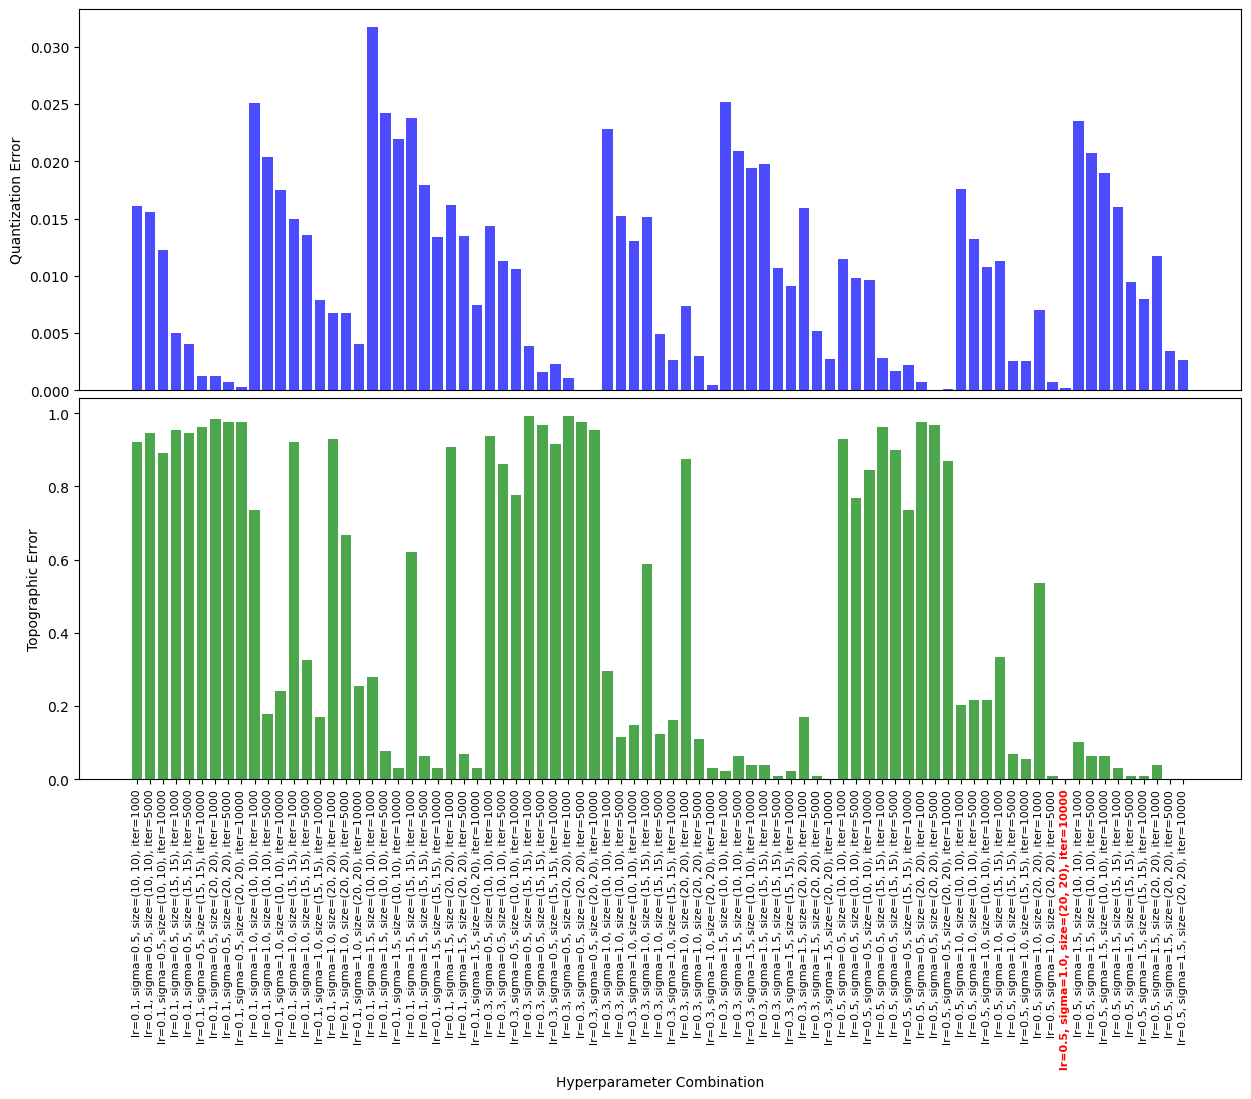

Best compromise hyperparameter combination: lr=0.5, sigma=1.0, size=(20, 20), iter=10000


In [18]:
# Normalize the errors to bring them to the same scale
quantization_errors_norm = (quantization_errors - np.min(quantization_errors)) / (np.max(quantization_errors) - np.min(quantization_errors))
topographic_errors_norm = (topographic_errors - np.min(topographic_errors)) / (np.max(topographic_errors) - np.min(topographic_errors))

# Compute the combined score (sum of normalized errors)
combined_scores = quantization_errors_norm + topographic_errors_norm

# Find the index of the best compromise (minimum combined score)
best_compromise_idx = np.argmin(combined_scores)

# Highlight the x-axis label for the best compromise
plt.figure(figsize=(15, 10))  # Increase figure height for better spacing

# Plot quantization error
plt.subplot(2, 1, 1)  # First subplot (2 rows, 1 column, position 1)
plt.bar(range(len(quantization_errors)), quantization_errors, color='blue', alpha=0.7)
plt.xticks([])  # Remove x-axis labels for the first plot
plt.ylabel("Quantization Error")

# Plot topographic error
plt.subplot(2, 1, 2)  # Second subplot (2 rows, 1 column, position 2)
plt.bar(range(len(topographic_errors)), topographic_errors, color='green', alpha=0.7)

# Highlight the x-axis label for the best compromise
x_labels = labels.copy()
xticks = plt.xticks(range(len(labels)), x_labels, rotation=90, fontsize=8)
for i, label in enumerate(xticks[1]):  # xticks[1] contains the Text objects for the labels
    if i == best_compromise_idx:
        label.set_color('red')  # Highlight the label in red
        label.set_fontweight('bold')  # Optionally make it bold

plt.ylabel("Topographic Error")
plt.xlabel("Hyperparameter Combination")

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.02)

plt.show()

# Print the best compromise hyperparameter combination
print(f"Best compromise hyperparameter combination: {labels[best_compromise_idx]}")

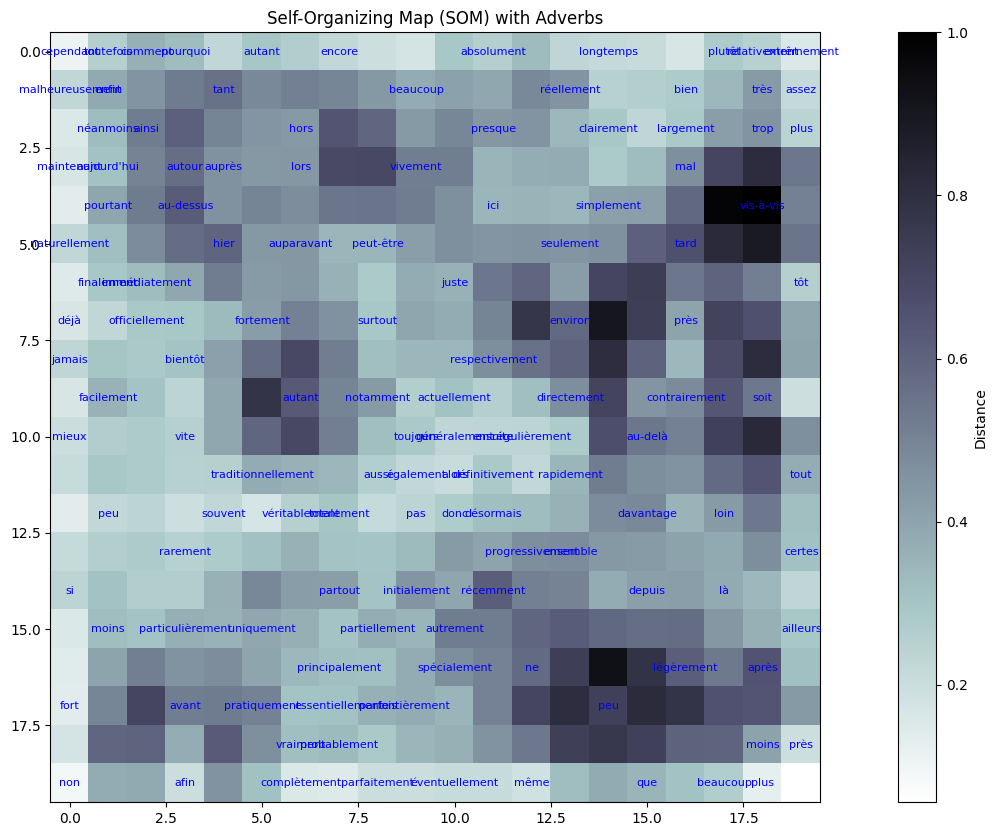

In [19]:
som = MiniSom(x=20, y=20, input_len=X.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_normalized)

# Train the SOM
som.train_random(X_normalized, num_iteration=10000)

# Map each data point to its winning neuron
winning_neurons = np.array([som.winner(x) for x in X_normalized])

# Group data points by their winning neurons
clusters = {}
for i, neuron in enumerate(winning_neurons):
    neuron = tuple(neuron)  # Convert numpy array to tuple
    if neuron not in clusters:
        clusters[neuron] = []
    clusters[neuron].append(i)

# # Map cluster indices back to original data (adv keys)
clustered_data = {}
for neuron, indices in clusters.items():

    clustered_data[neuron] = [corpus.idx2lexunit(i) for i in indices]

# Visualize the SOM with adverbs in each square
plt.figure(figsize=(20, 10))

# Iterate over the clusters and plot the adverbs in each neuron
for neuron, indices in clusters.items():
    # Extract the adverbs corresponding to the indices
    adverbs = [corpus.idx2lexunit(i)[0] for i in indices]  # Extract the adverb part from the tuple
    adverbs_text = "\n".join(adverbs)  # Join adverbs with line breaks for better readability
    
    # Plot the adverbs in the corresponding neuron square
    plt.text(neuron[0], neuron[1], adverbs_text, 
             color='blue', fontsize=8, ha='center', va='center', wrap=True)

# Add the distance map as the background
plt.title("Self-Organizing Map (SOM) with Adverbs")
plt.imshow(som.distance_map().T, cmap='bone_r')  # Distance map as background
plt.colorbar(label='Distance')
plt.show()

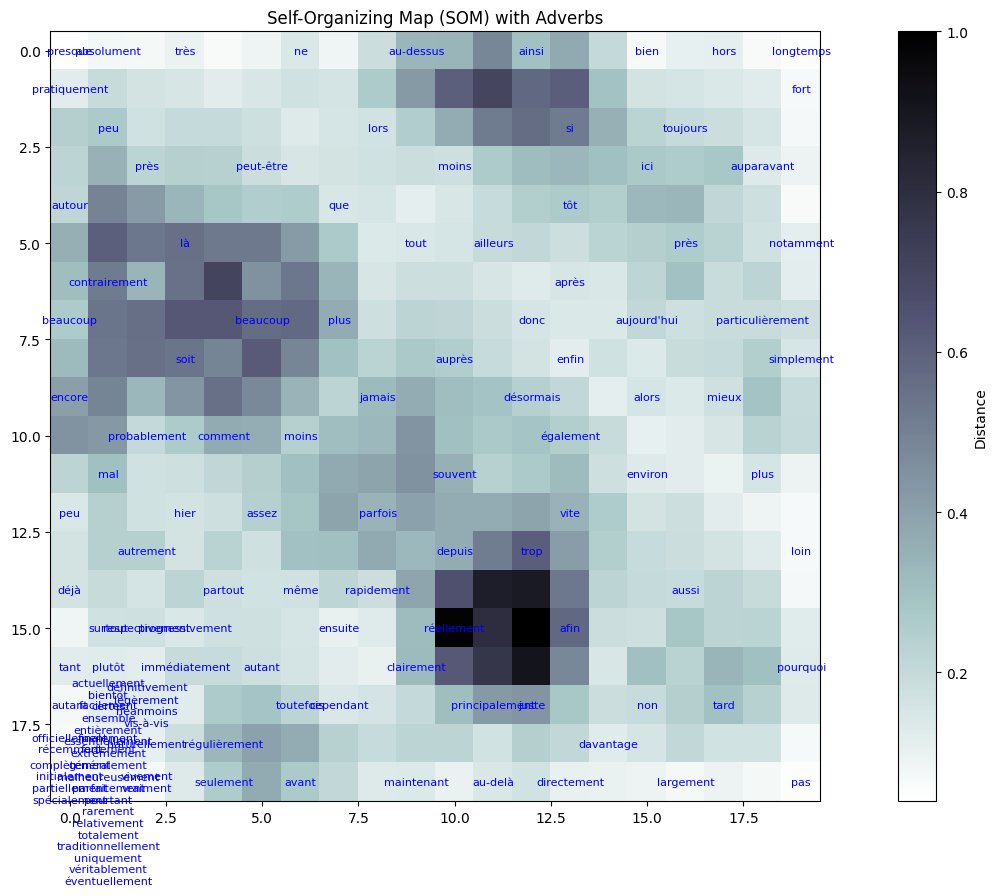

In [6]:
import matplotlib.pyplot as plt
# Visualize the SOM with adverbs in each square
plt.figure(figsize=(20, 10))

# Iterate over the clusters and plot the adverbs in each neuron
for neuron, indices in orig_dims['precision'].items():
    # Extract the adverbs corresponding to the indices
    adverbs = [corpus.idx2lexunit(i)[0] for i in indices]  # Extract the adverb part from the tuple
    adverbs_text = "\n".join(adverbs)  # Join adverbs with line breaks for better readability
    
    # Plot the adverbs in the corresponding neuron square
    plt.text(neuron[0], neuron[1], adverbs_text, 
             color='blue', fontsize=8, ha='center', va='center', wrap=True)

# Add the distance map as the background
plt.title("Self-Organizing Map (SOM) with Adverbs")
plt.imshow(som.distance_map().T, cmap='bone_r')  # Distance map as background
plt.colorbar(label='Distance')
plt.show()